In [8]:
import pandas as pd
import numpy as np
from os import listdir
import os
from collections import OrderedDict

Average frequency of top-100 tags from vacancies for each keyword-query.

In [2]:
mypath = './'
mean_val = {}
list_dir = list(filter(os.path.isdir, os.listdir(mypath)))[1:]

for d in list_dir:
    avg = []
    for f in listdir(mypath + d):
        avg.append(pd.read_csv(mypath + d + '/' + f)['1.0'].mean())
    mean_val[d] = np.array(avg).mean()
    
dict(sorted(mean_val.items(), key=lambda item: item[1], reverse=True))

{'EPAM': 0.3608409343171387,
 'микросервис': 0.13390309256397626,
 'res_php': 0.13268970853908715,
 'Intern_cyr': 0.1278216451756474,
 'res_Java': 0.11108126967429077,
 'res_Javascript': 0.10054028047185665,
 'intern': 0.0957461031986672,
 'devops': 0.08615741742940453,
 'spark': 0.0800994213879035,
 'res_Data scientist': 0.0777702813030677,
 'res_Python': 0.07708974749775546,
 'Typescript': 0.07268841035085528,
 'Javascript': 0.064768570312551,
 'Frontend': 0.06214428387063738,
 'php': 0.059208376221426474,
 'Golang': 0.057288721704986834,
 'data': 0.05458145765084969,
 'C%23': 0.054209279591240014,
 'Java': 0.046949928690950195,
 'sql': 0.04384036623811661,
 'Data scientist': 0.043596768682508495,
 'C%2B%2B': 0.042663775341694875,
 'python': 0.04037542479227292}

Average frequency of top-5 tags from vacancies for each keyword-query.

In [3]:
for d in list_dir:
    avg = []
    for f in listdir(mypath + d):
        avg.append(pd.read_csv(mypath + d + '/' + f)['1.0'].iloc[:5].mean())
    mean_val[d] = np.array(avg).mean()
    
dict(sorted(mean_val.items(), key=lambda item: item[1], reverse=True))

{'res_php': 0.8023845459495609,
 'микросервис': 0.7075690169993805,
 'EPAM': 0.6341346770067754,
 'Intern_cyr': 0.5994251019348278,
 'res_Java': 0.5916026858932735,
 'spark': 0.5841719746056094,
 'res_Javascript': 0.5801256101731803,
 'devops': 0.5769620290825739,
 'res_Python': 0.5083134564875282,
 'Typescript': 0.5038913170854143,
 'Frontend': 0.46556203957459663,
 'intern': 0.4506057952801332,
 'php': 0.4301282075606597,
 'Golang': 0.42106561030478706,
 'Javascript': 0.40643220731238844,
 'res_Data scientist': 0.38644743968488426,
 'C%2B%2B': 0.385481488124171,
 'Java': 0.3826800590910149,
 'data': 0.3644870198759891,
 'C%23': 0.36055121210837715,
 'python': 0.3340937136555792,
 'Data scientist': 0.302983237218452,
 'sql': 0.2451228037789032}

Average frequency of top-100 tags from vacancies for each keyword-query in last date for graphs.

In [4]:
#updateable tags
list_dir = ['C%23', 'C%2B%2B', 'Data', 'Data scientist', 'DevOps', 'Frontend', 'Golang', 'Intern',\
            'Intern_cyr', 'Java', 'Javascript', 'php', 'Python', 'Spark', 'SQL', 'Typescript', 'микросервис']

In [5]:
mypath = './'
ordered_dict = OrderedDict()

for d in list_dir:
    avg = []
    avg.append(pd.read_csv(mypath + d + '/' + listdir(mypath + d)[-1])['1.0'].mean())
    ordered_dict[d] = np.array(avg).mean()
    
ordered_dict = dict(sorted(ordered_dict.items(), key=lambda item: item[1], reverse=True))
# ordered_dict

Extracting date from names of files.

In [6]:
import re

date_x = ['9']
for name_file in listdir(mypath + '/Python'):
    date_x.append(re.findall('[0-9]{4}-[0-9]{2}-[0-9]{2}', name_file)[0])

Median frequency of top-20 tags from vacancies for each keyword-query and date, sorted by last date.

C:\Users\ksn\AppData\Local\Temp\ipykernel_12372\3916825495.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sorted(date_x, reverse=True), rotation=90)


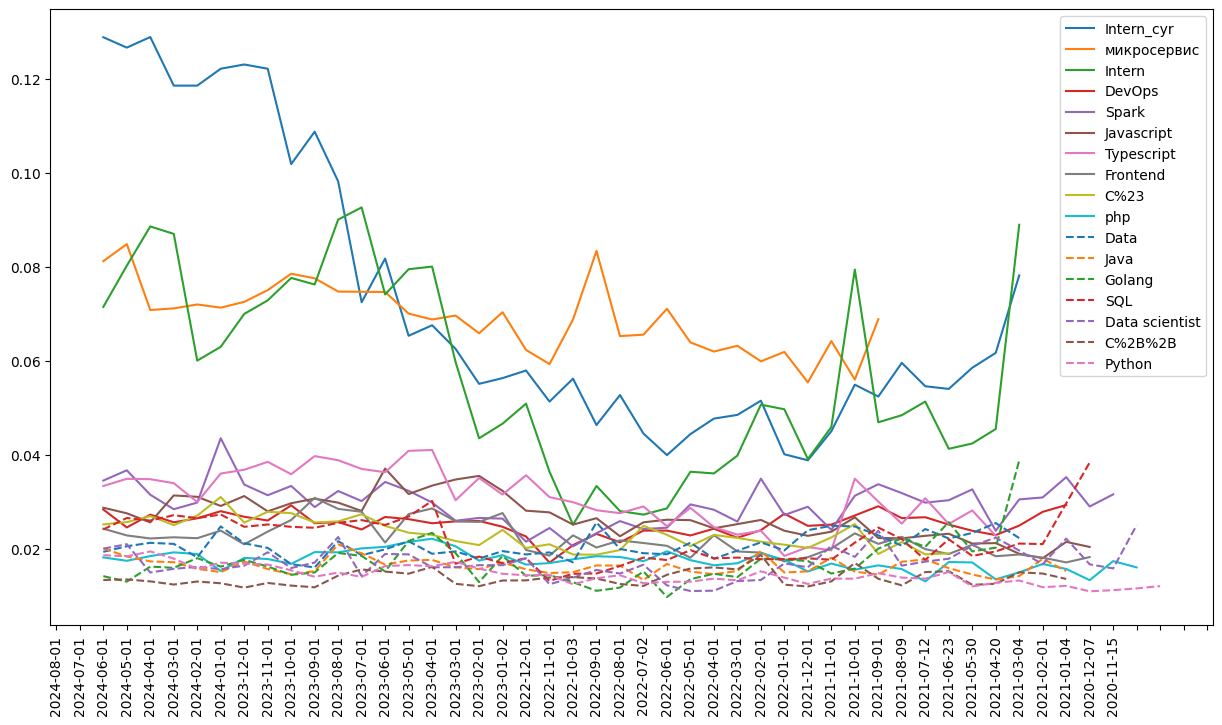

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


all_val = ordered_dict
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

for d in list_dir:
    val = []
    for f in listdir(mypath + d):
        val.append(pd.read_csv(mypath + d + '/' + f)['1.0'].median())
    all_val[d] = val[::-1]

col = ""

for i in all_val.keys():
    if col != 'php':
        ax.plot(all_val[i])
        col = i
    else:
        ax.plot(all_val[i], linestyle='--')
        col = 'php'

ax.legend([i for i in all_val.keys()])
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_xticklabels(sorted(date_x, reverse=True), rotation=90)
plt.show()